## Creating a GeoDataFrame from scratch
##### Input Geometries

In [1]:
from shapely import Point, Polygon, LineString, MultiPoint, MultiLineString, MultiPolygon, GeometryCollection

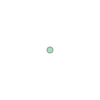

In [2]:
point = Point(0,0)
point

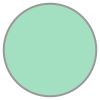

In [3]:
circle = Point(1,1).buffer(0.5)  # Create a circle with radius 0.5 around the point (1,1)
circle

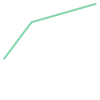

In [4]:
line = LineString([(2,2), (3.5,4), (7,5)])  # Create a line connecting the points (2,2), (3.5,4), and (7,5)
line

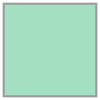

In [5]:
square = Polygon([(3,0), (3,1), (4,1), (4,0)])  # Create a square with corners at (3,0), (3,1), (4,1), and (4,0)
square

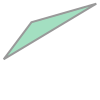

In [6]:
triangle = LineString([(2,2+1.5), (3.5,4+1.5), (7,5+1.5)]).convex_hull
triangle

##### Create a GeoDataFrame

In [7]:
geo_data = { "point": point,
              "circle": circle,
              "line": line,
              "square": square,
              "triangle": triangle }

geo_data

{'point': <POINT (0 0)>,
 'circle': <POLYGON ((1.5 1, 1.498 0.951, 1.49 0.902, 1.478 0.855, 1.462 0.809, 1.441 0...>,
 'line': <LINESTRING (2 2, 3.5 4, 7 5)>,
 'square': <POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))>,
 'triangle': <POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))>}

In [8]:
import geopandas as gpd

In [9]:
gdf = gpd.GeoDataFrame(geo_data.items(), columns=["geo_name", "geometry"])
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))"


In [10]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

##### Simple Functions and Computations

In [11]:
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))"


In [12]:
gdf['geometry_type'] = gdf['geometry'].apply(lambda x: type(x).__name__)  # Add a new column to the GeoDataFrame that contains the type of each geometry
gdf

,geo_name,geometry,geometry_type
0,point,POINT (0 0),Point
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon


In [13]:
gdf['geometry_buffer'] = gdf['geometry'].apply(lambda x: x.buffer(0.5))  # Add a new column to the GeoDataFrame that contains a buffer of 0.5 around each geometry
gdf

,geo_name,geometry,geometry_type,geometry_buffer
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0...."
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon,"POLYGON ((1.9994 1.02453, 1.9994 0.97547, 1.99..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4...."
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0..."
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2...."


In [14]:
gdf['geometry_length'] = gdf['geometry'].apply(lambda x: x.length).tolist()  # Add a new column to the GeoDataFrame that contains the length of each geometry
gdf['geometry_area'] = gdf['geometry'].apply(lambda x: x.area).tolist()  # Add a new column to the GeoDataFrame that contains the area of each geometry
gdf

,geo_name,geometry,geometry_type,geometry_buffer,geometry_length,geometry_area
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",0.000000,0.000000
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon,"POLYGON ((1.9994 1.02453, 1.9994 0.97547, 1.99...",3.140331,0.784137
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4....",6.140055,0.000000
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0...",4.000000,1.000000
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2....",11.971007,2.750000


#### Visualizing synthetic data with GeoPandas

<Axes: >

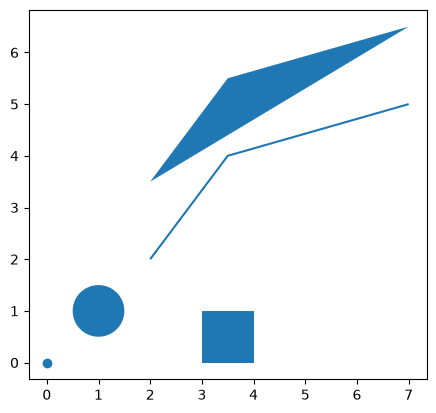

In [15]:
gdf.plot()

In [16]:
import matplotlib.pyplot as plt

<Axes: >

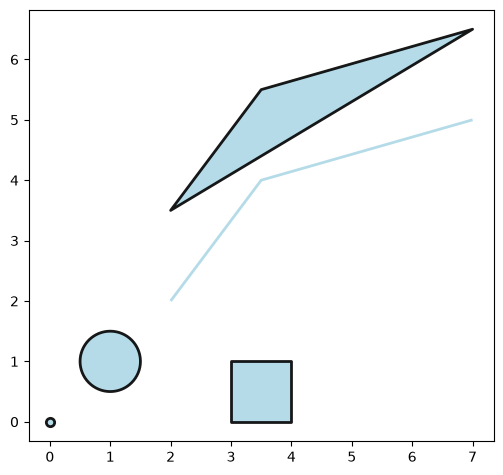

In [17]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax, 
         color='lightblue', 
         edgecolor='black',
         linewidth=2,
         alpha=0.9)

<Axes: >

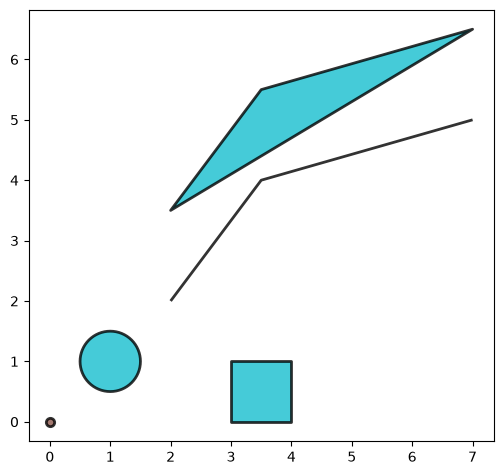

In [18]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax,
         column='geometry_type',  # Color the geometries based on their type
         edgecolor='black',
         linewidth=2,
         alpha=0.8)


<Axes: >

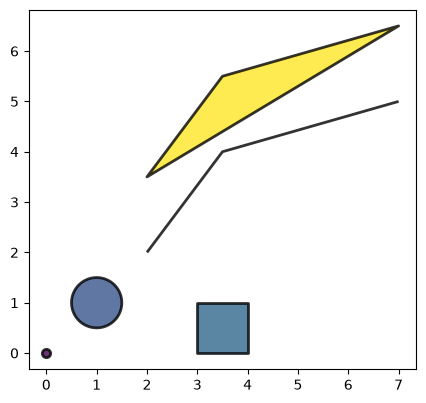

In [19]:
f, ax = plt.subplots(1,1,figsize=(5,5))

gdf.plot(ax=ax,
         column='geometry_length',
         cmap='viridis',  # Use the 'viridis' colormap to color the geometries based on their length
         edgecolor='black',
         linewidth=2,
         alpha=0.8)

#### Visualizing sample data with GeoPandas

In [20]:
import geopandas as gpd
import geodatasets
from geodatasets import get_path

In [21]:
nybb = gpd.read_file(get_path('nybb')) # Load the New York boroughs dataset from GeoPandas
nybb

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [22]:
import matplotlib.pyplot as plt

<Axes: >

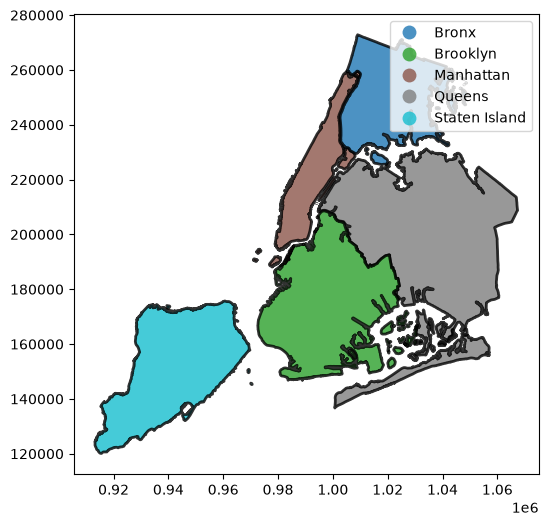

In [23]:
f, ax = plt.subplots(1,1,figsize=(6,6))

nybb.plot(ax=ax, column ='BoroName', linewidth=2, cmap = 'tab10', edgecolor='black', alpha=0.8, legend=True)

(np.float64(905464.7390380859),
 np.float64(1075092.8783935546),
 np.float64(112485.76063504723),
 np.float64(280480.4142594267))

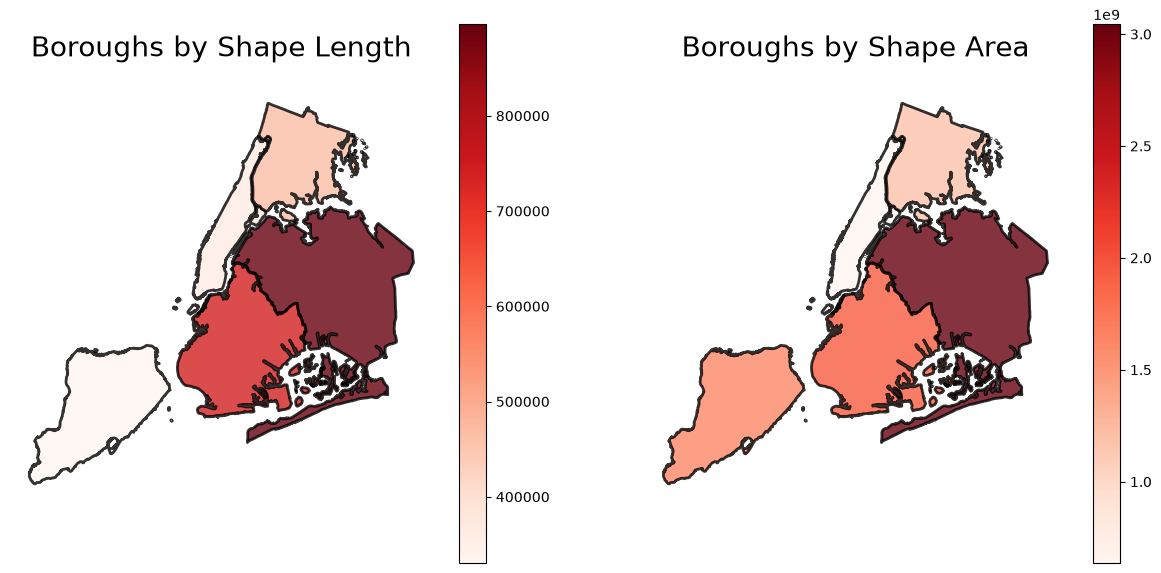

In [24]:
f, ax = plt.subplots(1,2,figsize=(15,7))

nybb.plot(column='Shape_Leng', ax=ax[0], cmap='Reds', edgecolor='black', linewidth=2, alpha=0.8, legend=True)
nybb.plot(column='Shape_Area', ax=ax[1], cmap='Reds', edgecolor='black', linewidth=2, alpha=0.8, legend=True)

ax[0].set_title('Boroughs by Shape Length', fontsize=20, pad=20)
ax[1].set_title('Boroughs by Shape Area', fontsize=20, pad=20)

ax[0].axis('off')
ax[1].axis('off')

* The final visualization shows that the larger a borough is in area, the longer its boundary (perimeter) tends to be. This is why the two maps, colored by area and perimeter, look quite similar. 
* The different shades of red also reveal variations in the spread of these values across boroughs. 
* This simple but important insight helps in understanding how spatial attributes like size and boundary length relate, which is a key step in extracting meaningful geospatial insights from data.

#### Map Projections
##### Quering CRS

In [25]:
nybb

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [51]:
# Natural Earth low-resolution countries dataset
world = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)
world = world[['POP_EST', 'CONTINENT', 'NAME', 'ISO_A3', 'GDP_MD', 'geometry']]
world.head()

,POP_EST,CONTINENT,NAME,ISO_A3,GDP_MD,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [52]:
print(world.crs)  # Print the coordinate reference system (CRS) of the GeoDataFrame
print(nybb.crs)  # Print the coordinate reference system (CRS) of the GeoDataFrame

EPSG:4326
EPSG:2263


In [53]:
nybb.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [54]:
world.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

#### Global and Local CRS

In [57]:
world_nyc =world.to_crs(nybb.crs)  # Reproject the world GeoDataFrame to the same CRS as the nybb GeoDataFrame
print(world_nyc.crs)  # Print the coordinate reference system (CRS) of the reprojected world GeoDataFrame

EPSG:2263


In [58]:
world_nyc.head()

,POP_EST,CONTINENT,NAME,ISO_A3,GDP_MD,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((-44383455.739 7369894.94, -446..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((39414397.961 10933271.416, 39488381...."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((20715700.071 3126064.149, 20732751.1..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-10260684.663 6449440.91, -102..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-10260684.663 6449440.91, -967..."


<Axes: >

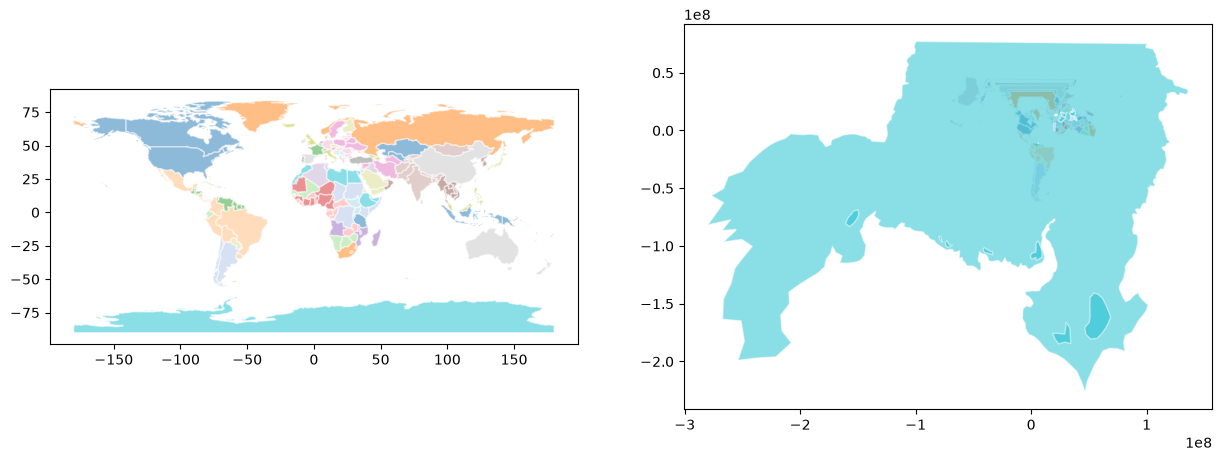

In [63]:
f, ax = plt.subplots(1,2,figsize=(15,7))

world.plot(ax=ax[0], edgecolor= 'w', cmap='tab20', alpha=0.5, linewidth=1)

world_nyc.plot(ax=ax[1], edgecolor= 'w', cmap='tab20', alpha=0.5, linewidth=1)

* The final visualization shows two maps side-by-side: one is a world map using a global coordinate reference system (CRS), and the other is the same world map transformed into a local CRS designed specifically for New York City. 

* The local CRS map looks distorted and twisted because it is optimized for accuracy only within the New York City area. This demonstrates that local CRSs provide very precise measurements for small regions but can cause significant distortion when applied globally.

*  The key takeaway is that choosing the right CRS is crucial—use a global CRS for worldwide data and a local CRS for detailed local analysis to get accurate spatial measurements.

##### Challenge: Understanding Geospatial Data Operations

In [64]:
# Importing necessary libraries
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

In [65]:
# Create geometries
top = Polygon([(0, 1), (0, 2), (2, 2), (2, 1)])
bottom = Polygon([(-1, 0), (-1, 1), (4, 1), (4, 0)])
wheel_front = Point(0, -0.5).buffer(0.5)
wheel_rear = Point(3, -0.5).buffer(0.5)

In [66]:
# Combine geometries into a list
geometries = [top, bottom, wheel_front, wheel_rear]
geometries

[<POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))>,
 <POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))>,
 <POLYGON ((0.5 -0.5, 0.498 -0.549, 0.49 -0.598, 0.478 -0.645, 0.462 -0.691, ...>,
 <POLYGON ((3.5 -0.5, 3.498 -0.549, 3.49 -0.598, 3.478 -0.645, 3.462 -0.691, ...>]

In [67]:
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=geometries)
gdf.crs = 4326
display(gdf)

,geometry
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))"
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))"
2,"POLYGON ((0.5 -0.5, 0.49759 -0.54901, 0.49039 ..."
3,"POLYGON ((3.5 -0.5, 3.49759 -0.54901, 3.49039 ..."


In [69]:
# Add a new column for geometry length
gdf['geometry_length'] = gdf.length

# Add a new column for geometry area
gdf['geometry_area'] = gdf.area

gdf.head()

/tmp/ipykernel_2139/3120514763.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_length'] = gdf.length
/tmp/ipykernel_2139/3120514763.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_area'] = gdf.area


,geometry,geometry_length,geometry_area
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))",6.000000,2.000000
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))",12.000000,5.000000
2,"POLYGON ((0.5 -0.5, 0.49759 -0.54901, 0.49039 ...",3.140331,0.784137
3,"POLYGON ((3.5 -0.5, 3.49759 -0.54901, 3.49039 ...",3.140331,0.784137


In [70]:
# Add a new column for geometry area
gdf['geometry'] = [g.buffer(0.2) for g in gdf.geometry.to_list()]
gdf.head()

,geometry,geometry_length,geometry_area
0,"POLYGON ((0 0.8, -0.0196 0.80096, -0.03902 0.8...",6.000000,2.000000
1,"POLYGON ((-1 -0.2, -1.0196 -0.19904, -1.03902 ...",12.000000,5.000000
2,"POLYGON ((0.69976 -0.49019, 0.69976 -0.50981, ...",3.140331,0.784137
3,"POLYGON ((3.69976 -0.49019, 3.69976 -0.50981, ...",3.140331,0.784137


<Axes: >

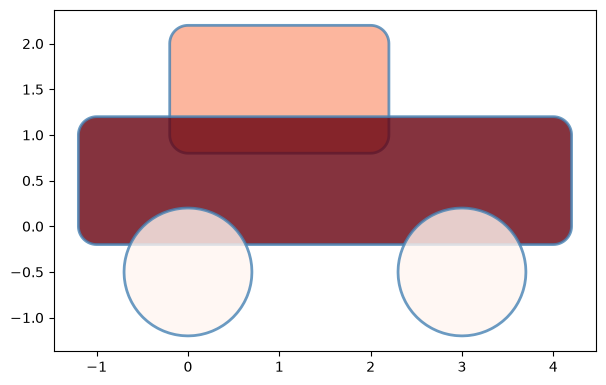

In [71]:
# Visualize the GeoDataFrame
f, ax = plt.subplots(1, 1, figsize=(7, 7))

gdf.plot(column='geometry_length', ax=ax, cmap='Reds', edgecolor='steelblue', linewidth=2, alpha=0.8)

In [72]:
# Create new projections
gdf_nyc = gdf.to_crs(2263)
gdf_hun = gdf.to_crs(23700)

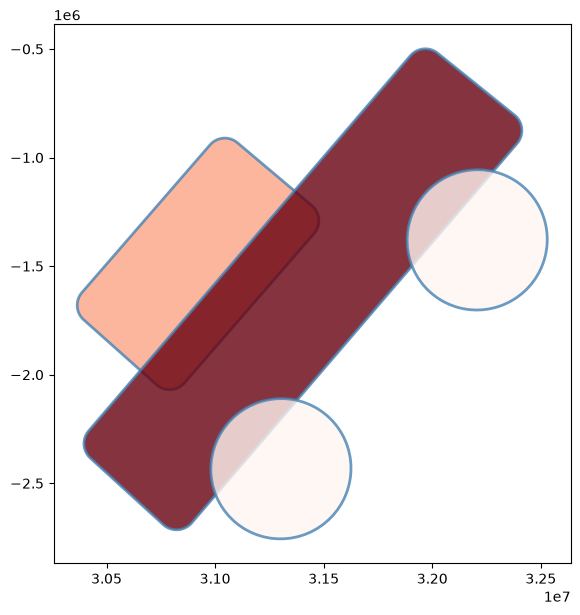

In [73]:
# Visualize the GeoDataFrame
f, ax = plt.subplots(1, 1, figsize=(7, 7))
gdf_nyc.plot(column='geometry_length', ax=ax, cmap='Reds', edgecolor='steelblue', linewidth=2, alpha=0.8)
plt.show()

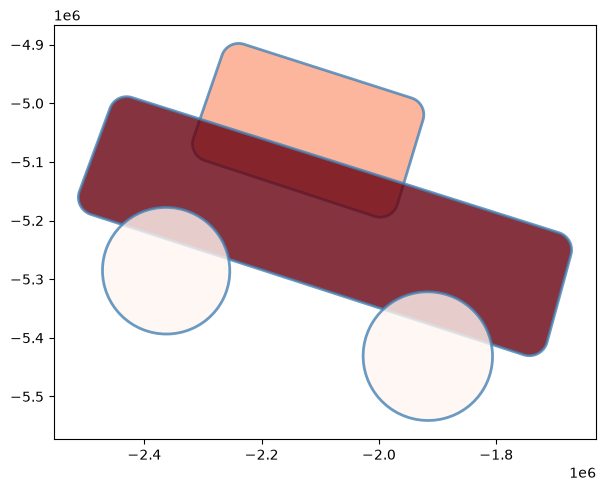

In [74]:
# Visualize the GeoDataFrame
f, ax = plt.subplots(1, 1, figsize=(7, 7))
gdf_hun.plot(column='geometry_length', ax=ax, cmap='Reds', edgecolor='steelblue', linewidth=2, alpha=0.8)
plt.show()